In [44]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("APL_Logistics.csv",encoding="latin1")

Cleaning

In [4]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [43]:
df["Customer Zipcode"].unique().shape

(996,)

In [5]:
df[['Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity', 'Sales', 'Order Item Total',
    'Order Profit Per Order', 'Order Region', 'Order State']].isnull().sum()

Order Customer Id           0
Order Item Discount         0
Order Item Discount Rate    0
Order Item Product Price    0
Order Item Profit Ratio     0
Order Item Quantity         0
Sales                       0
Order Item Total            0
Order Profit Per Order      0
Order Region                0
Order State                 0
dtype: int64

In [6]:
df[['Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Profit Ratio',
    'Order Item Quantity', 'Sales', 'Order Item Total',
    'Order Profit Per Order', 'Order Region', 'Order State']].dtypes

Order Customer Id             int64
Order Item Discount         float64
Order Item Discount Rate    float64
Order Item Product Price    float64
Order Item Profit Ratio     float64
Order Item Quantity           int64
Sales                       float64
Order Item Total            float64
Order Profit Per Order      float64
Order Region                    str
Order State                     str
dtype: object

In [44]:
df['Customer Lname'] = df['Customer Lname'].fillna('Unknown')

In [7]:
df.columns.shape

(40,)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order City                           str
Order Country   

In [10]:
df[df['Sales'] > 0]

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,TRANSFER,6,4,-107.96,161.87,Late delivery,1,76,Women's Clothing,Caguas,...,1,215.82,161.87,-107.96,Southeast Asia,Java Occidental,PROCESSING,Summer dresses,215.82,Standard Class
180515,DEBIT,2,4,-126.56,172.66,Advance shipping,0,76,Women's Clothing,Plainfield,...,1,215.82,172.66,-126.56,Southeast Asia,Java Occidental,COMPLETE,Summer dresses,215.82,Standard Class
180516,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,...,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,Smart watch,327.75,Standard Class
180517,PAYMENT,4,4,1.53,10.91,Shipping on time,0,74,Toys,Berwyn,...,1,11.54,10.91,1.53,Southeast Asia,Java Occidental,PENDING_PAYMENT,Toys,11.54,Standard Class


In [14]:
df[df["Order Item Discount Rate"]>1].shape

(0, 40)

Total Revenue

In [16]:
Total_revenue=df["Sales"].sum()
Total_revenue

np.float64(36784734.31)

Total Profit

In [17]:
Total_profit=df["Order Profit Per Order"].sum()
Total_profit

np.float64(3966902.9699999997)

Profit Margin(%)

In [18]:
Profit_margin=(Total_profit/Total_revenue)*100
Profit_margin

np.float64(10.784101188741193)

Revenue Vs Profit Trend

In [22]:
region_summary = df.groupby('Order Region')[['Sales','Order Profit Per Order']].sum()
region_summary['Profit Margin %'] = (region_summary['Order Profit Per Order'] / region_summary['Sales']) * 100
region_summary

,Sales,Order Profit Per Order,Profit Margin %
Order Region,,,
Canada,186861.04,23900.71,12.790633
Caribbean,1651019.30,171825.64,10.407246
Central Africa,327263.01,33447.27,10.220303
Central America,5665711.99,616341.57,10.878449
Central Asia,109839.93,13045.28,11.876628
East Africa,376234.89,43167.73,11.473612
East of USA,1371111.96,156263.30,11.396830
Eastern Asia,1486401.31,147368.01,9.914416
Eastern Europe,774266.55,79717.05,10.295815


Profit Concentration Pattern 

In [27]:
top_customers = df.groupby('Customer Id')['Order Profit Per Order'].sum().sort_values(ascending=False).head(10)
top_customers

Customer Id
2641     2441.97
1657     2196.92
9833     1938.39
2626     1928.57
5004     1917.99
3735     1906.36
749      1855.15
5560     1831.46
10967    1822.33
5053     1813.34
Name: Order Profit Per Order, dtype: float64

In [28]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


Product Level Profitability

In [29]:
product_summary = df.groupby('Product Name')[['Sales','Order Profit Per Order']].sum()
product_summary

,Sales,Order Profit Per Order
Product Name,,
Adult dog supplies,41524.80,3589.26
Baby sweater,12229.56,1525.03
Bag Boy Beverage Holder,21116.55,3173.78
Bag Boy M330 Push Cart,16637.92,2969.11
Bowflex SelectTech 1090 Dumbbells,5999.90,1190.78
...,...,...
adidas Kids' F5 Messi FG Soccer Cleat,27327.19,2906.33
adidas Men's F10 Messi TRX FG Soccer Cleat,56330.61,8213.07
adidas Men's Germany Black Crest Away Tee,21475.00,2833.72


In [ ]:
#Margin
product_summary['Profit Margin %'] = (product_summary['Order Profit Per Order'] / product_summary['Sales']) * 100
product_summary

,Sales,Order Profit Per Order,Profit Margin %
Product Name,,,
Adult dog supplies,41524.80,3589.26,8.643654
Baby sweater,12229.56,1525.03,12.470032
Bag Boy Beverage Holder,21116.55,3173.78,15.029823
Bag Boy M330 Push Cart,16637.92,2969.11,17.845440
Bowflex SelectTech 1090 Dumbbells,5999.90,1190.78,19.846664
...,...,...,...
adidas Kids' F5 Messi FG Soccer Cleat,27327.19,2906.33,10.635305
adidas Men's F10 Messi TRX FG Soccer Cleat,56330.61,8213.07,14.580119
adidas Men's Germany Black Crest Away Tee,21475.00,2833.72,13.195437


In [32]:
#top products
top_products = product_summary.sort_values(by='Order Profit Per Order', ascending=False).head(10)
top_products

,Sales,Order Profit Per Order,Profit Margin %
Product Name,,,
Field & Stream Sportsman 16 Gun Fire Safe,6929653.50,756220.76,10.912822
Perfect Fitness Perfect Rip Deck,4421143.02,493828.30,11.169697
Diamondback Women's Serene Classic Comfort Bi,4118425.42,427455.57,10.379102
Nike Men's Free 5.0+ Running Shoe,3667633.20,379915.82,10.358610
Nike Men's Dri-FIT Victory Golf Polo,3147800.00,350421.03,11.132252
Pelican Sunstream 100 Kayak,3099845.00,324076.37,10.454599
O'Brien Men's Neoprene Life Vest,2888993.94,318451.43,11.022918
Nike Men's CJ Elite 2 TD Football Cleat,2891757.54,311902.82,10.785926
Under Armour Girls' Toddler Spine Surge Runni,1269082.65,126278.51,9.950377


In [33]:
#bottom products
bottom_products = product_summary.sort_values(by='Order Profit Per Order', ascending=True).head(10)
bottom_products

,Sales,Order Profit Per Order,Profit Margin %
Product Name,,,
SOLE E35 Elliptical,29999.85,-965.12,-3.217083
Bushnell Pro X7 Jolt Slope Rangefinder,6599.89,-255.95,-3.878095
SOLE E25 Elliptical,9999.90,-169.56,-1.695617
GoPro HERO3+ Black Edition Camera,12799.68,245.63,1.919032
Diamondback Girls' Clarity 24 Hybrid Bike 201,8399.72,284.42,3.386065
Polar Loop Activity Tracker,5937.30,326.20,5.494080
Cleveland Golf Women's 588 RTX CB Satin Chrom,8399.30,370.61,4.412392
CDs of rock,3059.59,383.85,12.545799
Garmin Forerunner 910XT GPS Watch,13999.65,391.13,2.793856


Category Level Profitability

In [34]:
category_summary = df.groupby('Category Name')[['Sales','Order Profit Per Order']].sum()
category_summary

,Sales,Order Profit Per Order
Category Name,,
Accessories,133671.51,16643.52
As Seen on TV!,20597.94,714.43
Baby,12229.56,1525.03
Baseball & Softball,94057.15,12762.13
Basketball,27099.33,1845.67
Books,12587.40,883.01
Boxing & MMA,85205.41,8641.37
CDs,3059.59,383.85
Cameras,267607.68,30289.80


In [35]:
category_summary['Profit Margin %'] = (category_summary['Order Profit Per Order'] / category_summary['Sales']) * 100
category_summary

,Sales,Order Profit Per Order,Profit Margin %
Category Name,,,
Accessories,133671.51,16643.52,12.451060
As Seen on TV!,20597.94,714.43,3.468454
Baby,12229.56,1525.03,12.470032
Baseball & Softball,94057.15,12762.13,13.568485
Basketball,27099.33,1845.67,6.810759
Books,12587.40,883.01,7.015031
Boxing & MMA,85205.41,8641.37,10.141809
CDs,3059.59,383.85,12.545799
Cameras,267607.68,30289.80,11.318733


In [37]:
category_summary = category_summary.sort_values(by='Order Profit Per Order', ascending=False)
category_summary

,Sales,Order Profit Per Order,Profit Margin %
Category Name,,,
Fishing,6929653.50,756220.76,10.912822
Cleats,4431942.66,494636.92,11.160725
Camping & Hiking,4118425.42,427455.57,10.379102
Cardio Equipment,3694843.20,383011.10,10.366099
Women's Apparel,3147800.00,350421.03,11.132252
Water Sports,3113844.60,325146.96,10.441978
Indoor/Outdoor Games,2888993.94,318451.43,11.022918
Men's Footwear,2891757.54,311902.82,10.785926
Shop By Sport,1309522.02,129813.96,9.913080


Customer level Aggregation

In [41]:
# Customer wise sales & profit
customer_summary = df.groupby('Customer Id')[['Sales','Order Profit Per Order']].sum()

# Profit margin %
customer_summary['Profit Margin %'] = (customer_summary['Order Profit Per Order'] / customer_summary['Sales']) * 100

# Customer Value Index (profit contribution per customer)
customer_summary['Customer Value Index'] = customer_summary['Order Profit Per Order'] / customer_summary['Sales']

# Bottom 10 loss-making customers
bottom_customers = customer_summary.sort_values(by='Order Profit Per Order', ascending=True).head(10)

bottom_customers


,Sales,Order Profit Per Order,Profit Margin %,Customer Value Index
Customer Id,,,,
1428,3883.67,-3868.56,-99.610935,-0.996109
14086,1500.00,-3442.50,-229.500000,-2.295000
18109,1500.00,-3366.00,-224.400000,-2.244000
14313,1500.00,-3000.00,-200.000000,-2.000000
18061,1500.00,-2592.00,-172.800000,-1.728000
14113,1500.00,-2550.00,-170.000000,-1.700000
14090,1500.00,-2351.25,-156.750000,-1.567500
14398,1500.00,-2328.00,-155.200000,-1.552000
14306,1500.00,-2280.00,-152.000000,-1.520000


In [43]:

# Top 10 profitable customers
top_customers = customer_summary.sort_values(by='Order Profit Per Order', ascending=False).head(10)
top_customers

,Sales,Order Profit Per Order,Profit Margin %,Customer Value Index
Customer Id,,,,
2641,9130.92,2441.97,26.743964,0.267440
1657,9223.71,2196.92,23.818182,0.238182
9833,6059.38,1938.39,31.989907,0.319899
2626,6274.36,1928.57,30.737318,0.307373
5004,8164.70,1917.99,23.491249,0.234912
3735,6019.33,1906.36,31.670634,0.316706
749,7649.38,1855.15,24.252292,0.242523
5560,6528.21,1831.46,28.054551,0.280546
10967,5734.41,1822.33,31.778858,0.317789


Discount Impact Diagnostics

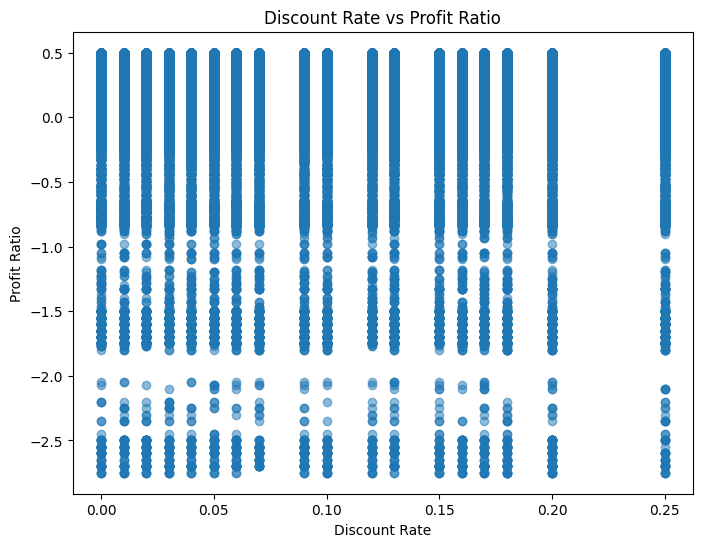

In [45]:
# Discount rate vs profit ratio correlation
discount_analysis = df[['Order Item Discount Rate','Order Item Profit Ratio']]

# Scatter plot to visualize relationship
plt.figure(figsize=(8,6))
plt.scatter(discount_analysis['Order Item Discount Rate'], discount_analysis['Order Item Profit Ratio'], alpha=0.5)
plt.xlabel("Discount Rate")
plt.ylabel("Profit Ratio")
plt.title("Discount Rate vs Profit Ratio")
plt.show()


Threshold detection

In [46]:
# Average profit ratio by discount rate bucket
df['Discount Bucket'] = pd.cut(df['Order Item Discount Rate'], bins=[0,0.1,0.2,0.3,0.5,1], labels=['0-10%','10-20%','20-30%','30-50%','50-100%'])

bucket_summary = df.groupby('Discount Bucket')['Order Item Profit Ratio'].mean()
print(bucket_summary)


Discount Bucket
0-10%     0.121745
10-20%    0.117332
20-30%    0.127158
Name: Order Item Profit Ratio, dtype: float64


Region level Profitability

In [48]:
# Region wise sales & profit
region_summary = df.groupby('Order Region')[['Sales','Order Profit Per Order']].sum()

# Profit margin %
region_summary['Profit Margin %'] = (region_summary['Order Profit Per Order'] / region_summary['Sales']) * 100

# Sort by profit
region_summary = region_summary.sort_values(by='Order Profit Per Order', ascending=False)

region_summary


,Sales,Order Profit Per Order,Profit Margin %
Order Region,,,
Western Europe,5894380.66,625446.08,10.610887
Central America,5665711.99,616341.57,10.878449
South America,2960881.35,335154.40,11.319413
Northern Europe,2155830.61,233450.60,10.828801
Southern Europe,2047918.78,230829.23,11.271405
Southeast Asia,1932495.53,211342.82,10.936264
Oceania,2016654.16,201478.02,9.990708
Caribbean,1651019.30,171825.64,10.407246
South Asia,1553680.89,165703.90,10.665247


Market level Profitabilit

In [50]:
# Market wise sales & profit
market_summary = df.groupby('Market')[['Sales','Order Profit Per Order']].sum()

# Profit margin %
market_summary['Profit Margin %'] = (market_summary['Order Profit Per Order'] / market_summary['Sales']) * 100

# Sort by profit
market_summary = market_summary.sort_values(by='Order Profit Per Order', ascending=False)

market_summary


,Sales,Order Profit Per Order,Profit Margin %
Market,,,
Europe,10872396.60,1169442.96,10.756073
LATAM,10277612.64,1123321.61,10.929791
Pacific Asia,8273743.58,857753.44,10.367175
USCA,5066528.61,564313.78,11.138075
Africa,2294452.88,252071.18,10.986113


Country level Profitability

In [52]:
# Country wise sales & profit
country_summary = df.groupby('Order Country')[['Sales','Order Profit Per Order']].sum()

# Profit margin %
country_summary['Profit Margin %'] = (country_summary['Order Profit Per Order'] / country_summary['Sales']) * 100

# Sort by profit
country_summary = country_summary.sort_values(by='Order Profit Per Order', ascending=False)

country_summary


,Sales,Order Profit Per Order,Profit Margin %
Order Country,,,
Estados Unidos,4879667.57,540413.07,11.074793
Francia,2879942.31,327828.58,11.383165
México,2633195.24,303278.37,11.517504
Alemania,2074171.78,194827.08,9.393006
Brasil,1594319.92,186713.64,11.711178
...,...,...,...
Mongolia,15481.74,-286.23,-1.848823
Bosnia y Herzegovina,8869.09,-327.38,-3.691247
Ruanda,18913.02,-330.02,-1.744935


In [53]:
# KPI Summary
kpi_summary = {
    "Total Revenue": df['Sales'].sum(),
    "Total Profit": df['Order Profit Per Order'].sum(),
    "Profit Margin %": (df['Order Profit Per Order'].sum() / df['Sales'].sum()) * 100,
    "Late Delivery %": df['Late_delivery_risk'].mean() * 100
}

print("KPI Summary:\n", kpi_summary)

# Top Categories
top_categories = df.groupby('Category Name')['Order Profit Per Order'].sum().sort_values(ascending=False).head(5)
print("\nTop Categories by Profit:\n", top_categories)

# Top Customers
top_customers = df.groupby('Customer Id')['Order Profit Per Order'].sum().sort_values(ascending=False).head(5)
print("\nTop Customers by Profit:\n", top_customers)

# Discount Impact
df['Discount Bucket'] = pd.cut(df['Order Item Discount Rate'], bins=[0,0.1,0.2,0.3,0.5,1], labels=['0-10%','10-20%','20-30%','30-50%','50-100%'])
discount_summary = df.groupby('Discount Bucket')['Order Item Profit Ratio'].mean()
print("\nDiscount Impact:\n", discount_summary)



KPI Summary:
 {'Total Revenue': np.float64(36784734.31), 'Total Profit': np.float64(3966902.9699999997), 'Profit Margin %': np.float64(10.784101188741193), 'Late Delivery %': np.float64(54.82913155955883)}

Top Categories by Profit:
 Category Name
Fishing             756220.76
Cleats              494636.92
Camping & Hiking    427455.57
Cardio Equipment    383011.10
Women's Apparel     350421.03
Name: Order Profit Per Order, dtype: float64

Top Customers by Profit:
 Customer Id
2641    2441.97
1657    2196.92
9833    1938.39
2626    1928.57
5004    1917.99
Name: Order Profit Per Order, dtype: float64

Discount Impact:
 Discount Bucket
0-10%     0.121745
10-20%    0.117332
20-30%    0.127158
Name: Order Item Profit Ratio, dtype: float64
